# Step 1: Data Exploration - Emergency Room Visits (DuckDB / Out-of-Core)
This notebook explores the processed Parquet datasets for Emergency Room (ER) visits for the *entire country* across all years (2017-2024).
By using DuckDB, we query billions of records without loading them into memory, obtaining country-wide aggregations.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# 1. Query the whole dataset using DuckDB
print("=== Total Country-Wide ER Visits (2017-2024) ===")

query_total = """
SELECT 
    SUM(Menores_1) as Menores_1,
    SUM(De_1_a_4) as De_1_a_4,
    SUM(De_5_a_14) as De_5_a_14,
    SUM(De_15_a_64) as De_15_a_64,
    SUM(De_65_y_mas) as De_65_y_mas
FROM read_parquet('../data/processed/urgencias_parquet/*.parquet')
"""
df_totals = duckdb.query(query_total).df()
display(df_totals)

=== Total Country-Wide ER Visits (2017-2024) ===


,Menores_1,De_1_a_4,De_5_a_14,De_15_a_64,De_65_y_mas
0,12606113.0,39550759.0,61080515.0,228587185.0,53449145.0


## Geographic Linkage Validation (Whole Country)
We load the Hospital Catalog into Pandas and use DuckDB to join it with the out-of-core Parquet files. This validates that all ER IDs in the country exist in our hospital map.

In [2]:
# Load hospitals into Pandas (safe for latin1 encoding)
hospitals_path = '../data/raw/Atenciones de Urgencia/Establecimientos de Salud/establecimientos_20260714.csv'
df_hosp = pd.read_csv(hospitals_path, sep=';', encoding='latin1')
df_hosp['EstablecimientoCodigoAntiguo'] = df_hosp['EstablecimientoCodigoAntiguo'].astype(str)

# Join Parquet with Pandas DataFrame via DuckDB
query_hospitals = """
SELECT 
    COUNT(DISTINCT u.IdEstablecimiento) as total_unique_er_hospitals_in_chile,
    COUNT(DISTINCT h.EstablecimientoCodigoAntiguo) as successfully_matched_hospitals
FROM read_parquet('../data/processed/urgencias_parquet/*.parquet') u
LEFT JOIN df_hosp h
ON u.IdEstablecimiento = h.EstablecimientoCodigoAntiguo
"""
df_hospitals_match = duckdb.query(query_hospitals).df()
print("\n=== Geographic Linkage Validation ===")
display(df_hospitals_match)


=== Geographic Linkage Validation ===


,total_unique_er_hospitals_in_chile,successfully_matched_hospitals
0,817,763


## Basic Visualization (with required text output)
As per our project rules, any plot must be accompanied by explicit textual output of the underlying data for maximum interpretability.

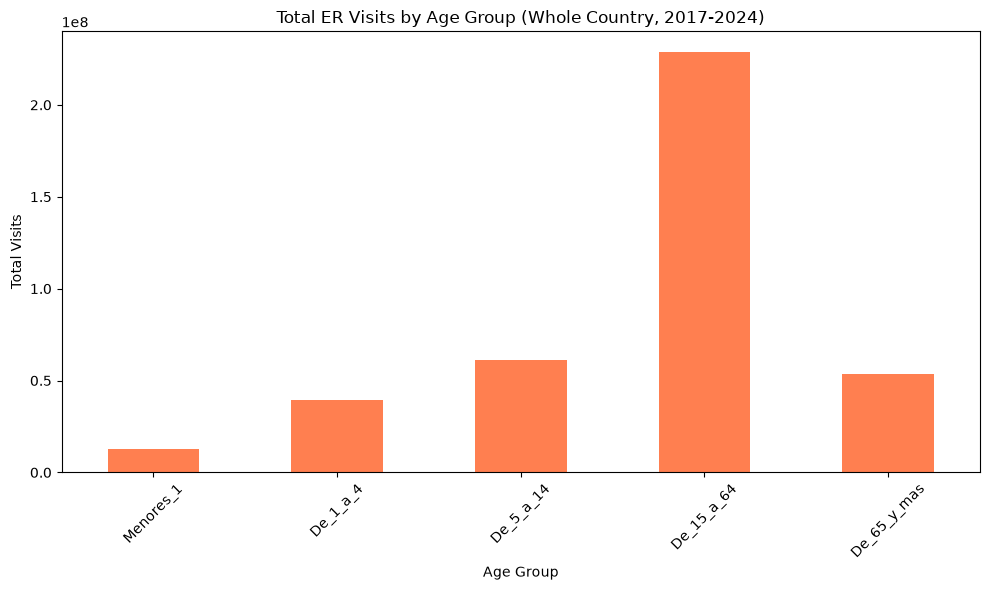


--- Textual Data Output for the Plot ---
Data: Distribution of ER Visits by Age Group (All Years, All Hospitals)
             Total Visits
Menores_1      12606113.0
De_1_a_4       39550759.0
De_5_a_14      61080515.0
De_15_a_64    228587185.0
De_65_y_mas    53449145.0
------------------------------------------


In [3]:
# Plotting the data
plt.figure(figsize=(10, 6))
totals_series = df_totals.iloc[0]
totals_series.plot(kind='bar', color='coral')
plt.title('Total ER Visits by Age Group (Whole Country, 2017-2024)')
plt.xlabel('Age Group')
plt.ylabel('Total Visits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# REQUIRED TEXT OUTPUT (Project Rule 3)
print("\n--- Textual Data Output for the Plot ---")
print("Data: Distribution of ER Visits by Age Group (All Years, All Hospitals)")
print(totals_series.to_frame(name='Total Visits').to_string())
print("------------------------------------------")

## Target Variable EDA: Respiratory Urgencies
As defined for this project, our target variable ($y$) is the daily total of Emergency Room visits for Respiratory Causes at a specific hospital. We will use the 'Hospital Guillermo Grant Benavente' (a major hospital in Concepción) as our case study.

=== Target Variable EDA: Hospital Guillermo Grant Benavente ===


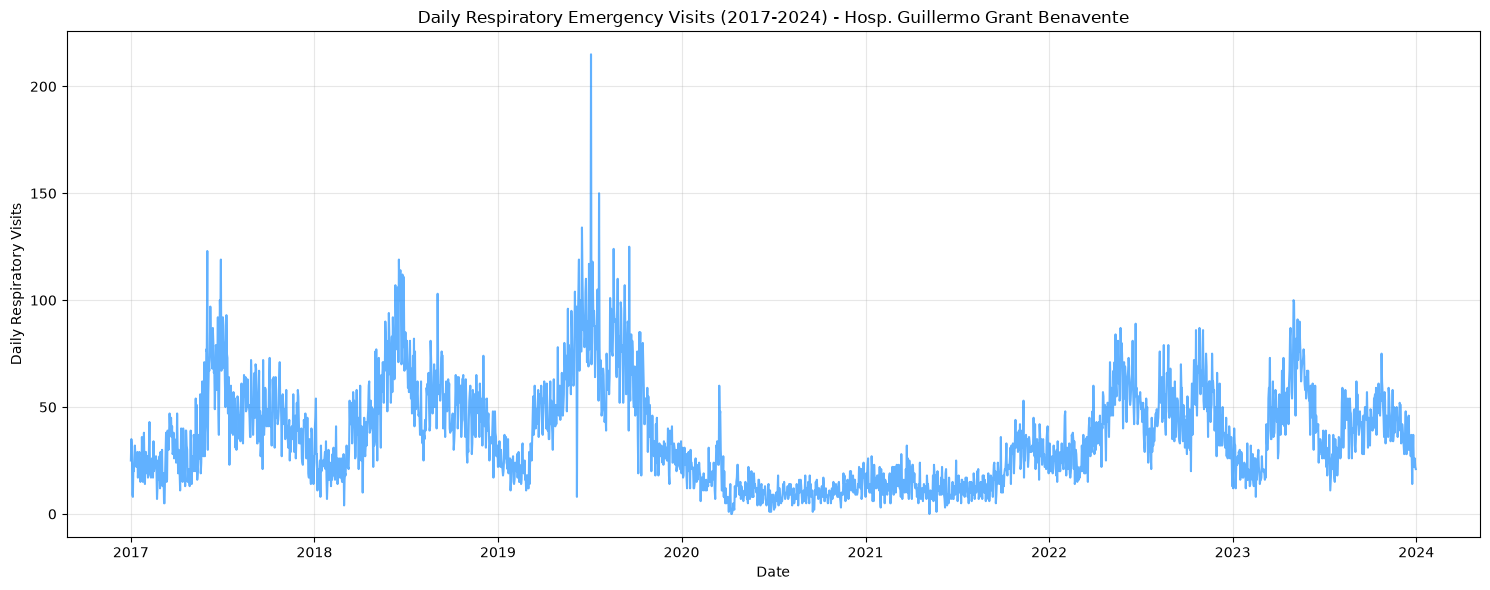


--- Textual Data Output for the Plot (Monthly Averages) ---
Data: Monthly Average of Daily Respiratory Visits (Hosp. Guillermo Grant Benavente)
            Total_Urgencias_Respiratorias
fecha                                    
2017-01-31                      23.645161
2017-02-28                      21.357143
2017-03-31                      28.741935
2017-04-30                      25.833333
2017-05-31                      35.258065
2017-06-30                      73.600000
2017-07-31                      57.612903
2017-08-31                      50.000000
2017-09-30                      47.366667
2017-10-31                      50.516129
2017-11-30                      40.900000
2017-12-31                      31.193548
...
            Total_Urgencias_Respiratorias
fecha                                    
2023-01-31                      23.354839
2023-02-28                      19.785714
2023-03-31                      39.354839
2023-04-30                      53.966667
2023-05-31 

In [4]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Query the target variable using DuckDB
query_eda = """
SELECT 
    fecha,
    SUM(Total) as Total_Urgencias_Respiratorias
FROM read_parquet('../data/processed/urgencias_parquet/*.parquet')
WHERE NEstablecimiento LIKE '%Grant Benavente%'
  AND GlosaCausa LIKE '%RESPIRATORIO%'
GROUP BY fecha
"""
df_eda = duckdb.query(query_eda).df()

# Process dates properly
df_eda['fecha'] = pd.to_datetime(df_eda['fecha'], format='%d/%m/%Y', errors='coerce')
df_eda = df_eda.dropna(subset=['fecha']).sort_values('fecha')

print("=== Target Variable EDA: Hospital Guillermo Grant Benavente ===")

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(df_eda['fecha'], df_eda['Total_Urgencias_Respiratorias'], color='dodgerblue', alpha=0.7)
plt.title('Daily Respiratory Emergency Visits (2017-2024) - Hosp. Guillermo Grant Benavente')
plt.xlabel('Date')
plt.ylabel('Daily Respiratory Visits')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# REQUIRED TEXT OUTPUT (Project Rule 3)
print("\n--- Textual Data Output for the Plot (Monthly Averages) ---")
print("Data: Monthly Average of Daily Respiratory Visits (Hosp. Guillermo Grant Benavente)")
df_monthly = df_eda.set_index('fecha').resample('ME').mean().dropna()
print(df_monthly.head(12).to_string())
print("...")
print(df_monthly.tail(12).to_string())
print("------------------------------------------")